In [1]:
import sys
path_to_pip_installs = "/tmp/test_env"
if path_to_pip_installs not in sys.path:
    sys.path.insert(0, path_to_pip_installs)

In [2]:
import torch
import data as Data
import model as Model
import argparse
import logging
import core.logger as Logger
import os
from math import *
import time
from util.visualizer import Visualizer
from PIL import Image
import numpy as np

In [16]:
from argparse import Namespace

args = Namespace(
    config="config/diffuseMorph_train_2D.json",
    phase="train",
    gpu_ids="0",
    debug=False,
)

opt = Logger.parse(args)

opt['datasets'].items()
phase = 'train'
dataset_opt = opt['datasets'][phase]

test_set = Data.create_dataset_2D(dataset_opt, phase)
test_loader = Data.create_dataloader(test_set, dataset_opt, phase)


export CUDA_VISIBLE_DEVICES=0


In [17]:
diffusion = Model.create_model(opt)

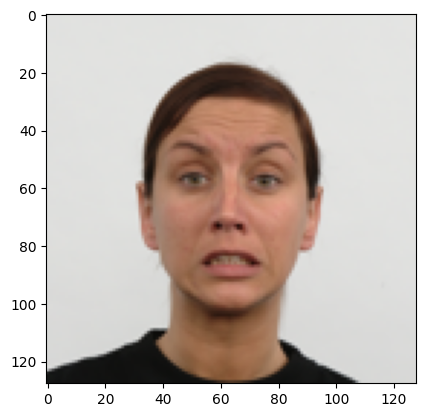

In [33]:
import matplotlib.pyplot as plt
tmp = test_set[0]["MC"]
# transform to integer
tmp = tmp.astype(int)
plt.imshow(tmp)

In [3]:
from prepare_data import prepare_data

In [4]:
input_path = "/home/students/studweilc1/MU-Diff/data/my_data2"
output_path = "/home/students/studweilc1/DiffuseMorph/dataset/mu_diff_bold"
moving_contrast = "BOLD"
fixed_contrast = "DIXON"

prepare_data(input_path, output_path, moving_contrast, fixed_contrast)

In [ ]:
import numpy as np
moving_data = np.load("/home/students/studweilc1/MU-Diff/data/my_data2/test/DIXON.npy")


(102, 256, 256)

In [44]:
# transform moving data to -1 1 range
moving_data = (moving_data - np.min(moving_data)) / (np.max(moving_data) - np.min(moving_data))

moving_data[0].max()

np.float32(0.9435626)

In [5]:
import torch
from data.MRI_dataset import MRIDataset
output_path = "/home/students/studweilc1/DiffuseMorph/dataset/mu_diff_bold"
# 2. Create the dataset
dataroot = output_path
train_dataset = MRIDataset(dataroot, split='test')

# 3. Create the DataLoader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

# You can now iterate through the train_loader to get your data
for i, data in enumerate(train_loader):
    print(f"Batch {i}:")
    print("Moving image shape:", data['M'].shape)
    print("Fixed image shape:", data['F'].shape)
    break


/tmp/test_env/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch 0:
Moving image shape: torch.Size([1, 1, 256, 256])
Fixed image shape: torch.Size([1, 1, 256, 256])


In [30]:
from data.RAFD_dataset import RAFDDataset as D
dataset = D("toy_sample/",
            split="train"
            )

## Test Dataloader

In [3]:
from argparse import Namespace

args = Namespace(
    config="config/diffuseMorph_train_MRI2D.json",
    phase="train",
    gpu_ids="0",
    debug=False,
)

opt = Logger.parse(args)

dataset_opt = opt["datasets"]["train"]
phase = 'train'

export CUDA_VISIBLE_DEVICES=0


In [4]:

train_set = Data.create_dataset_2D(dataset_opt, phase=phase, mri=True)
batchSize = opt['datasets']['train']['batch_size']
train_loader = Data.create_dataloader(train_set, dataset_opt, phase)

# You can now iterate through the train_loader to get your data
for i, data in enumerate(train_loader):
    print(f"Batch {i}:")
    print("Moving image shape:", data['M'].shape)
    print("Fixed image shape:", data['F'].shape)
    break

Creating MRI dataset
Batch 0:
Moving image shape: torch.Size([1, 1, 256, 256])
Fixed image shape: torch.Size([1, 1, 256, 256])


In [5]:
train_set[0]["M"].max()

tensor(0.8980)

In [7]:
data["M"].min()

tensor(-1.)

## Debug prepare data

In [36]:
import os
import numpy as np
from PIL import Image

def prepare_data(input_path, output_path, moving_contrast, fixed_contrast):
    """
    Prepares the data for the DiffuseMorph model by converting .npy files to .png images.

    Args:
        input_path (str): The path to the input data, which should contain train, val, and test subfolders.
        output_path (str): The path to save the processed data.
        moving_contrast (str): The name of the moving contrast (e.g., 'BOLD').
        fixed_contrast (str): The name of the fixed contrast (e.g., 'DIXON').
    """

    for split in ['train', 'val', 'test']:
        # Create output directories
        output_split_path = os.path.join(output_path, split)
        os.makedirs(output_split_path, exist_ok=True)

        # Load data from .npy files
        moving_data_path = os.path.join(input_path, split, moving_contrast + '.npy')
        fixed_data_path = os.path.join(input_path, split, fixed_contrast + '.npy')

        moving_data = np.load(moving_data_path)
        moving_data = (moving_data - np.min(moving_data)) / (np.max(moving_data) - np.min(moving_data))
        fixed_data = np.load(fixed_data_path)
        fixed_data = (fixed_data - np.min(fixed_data)) / (np.max(fixed_data) - np.min(fixed_data))

        # Save each slice as a PNG image
        for i in range(moving_data.shape[0]):
            # --- Moving Image ---
            # Normalize the slice to 0-255 and convert to uint8
            moving_slice_normalized = (moving_data[i] * 255.0).astype(np.uint8)
            #moving_slice_normalized = (255.0 * (moving_slice - np.min(moving_slice)) / (np.max(moving_slice) - np.min(moving_slice))).astype(np.uint8)
            moving_img = Image.fromarray(moving_slice_normalized)
            moving_img.save(os.path.join(output_split_path, f'moving_{i}.png'))

            # --- Fixed Image ---
            # Normalize the slice to 0-255 and convert to uint8
            fixed_slice_normalized = (fixed_data[i] * 255.0).astype(np.uint8)
            #fixed_slice_normalized = (255.0 * (fixed_slice - np.min(fixed_slice)) / (np.max(fixed_slice) - np.min(fixed_slice))).astype(np.uint8)
            fixed_img = Image.fromarray(fixed_slice_normalized)
            fixed_img.save(os.path.join(output_split_path, f'fixed_{i}.png'))

In [37]:
input_path = "/home/students/studweilc1/MU-Diff/data/my_data2"
output_path = "/home/students/studweilc1/DiffuseMorph/dataset/mu_diff_test"
moving_contrast = "BOLD"
fixed_contrast = "DIXON"

prepare_data(input_path, output_path, moving_contrast, fixed_contrast)

KeyboardInterrupt: 